In [ ]:
FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS
Objective:
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset. 
Dataset:
The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.
Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.
Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.
Part 3: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.
Deliverables:
●	Include visualizations and explanations for the choices and findings at each step.
●	Well-commented Python code that used to conduct the analysis and build the models.
Assessment Criteria:
●	Accuracy and completeness of the data preparation and exploration steps.
●	Justification for model selection and parameter tuning decisions.
●	Clarity and depth of the analysis in the diagnostics and model evaluation stages.
This assignment offers hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Part 1: Data Preparation
# =============================

# Load dataset
file_path = "/Users/SS/Downloads/exchange_rate.csv"
df = pd.read_csv("/Users/SS/Downloads/exchange_rate.csv")
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [27]:
df.iloc[:,0] = pd.to_datetime(df.iloc[:,0], dayfirst=True)
df = df.set_index(df.columns[0])

print(df.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


C:\Users\SS\AppData\Roaming\Python\Python313\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [20]:
import pandas as pd

df = pd.read_csv("/Users/SS/Downloads/exchange_rate.csv")

# Fix date column
df.iloc[:,0] = pd.to_datetime(df.iloc[:,0], dayfirst=True, errors='coerce')
df = df.dropna(subset=[df.columns[0]])

# Set index
df = df.set_index(df.columns[0])

# Fix dtype warning
df = df.infer_objects()

# Define rate column
rate_col = df.columns[0]

# Fill missing values (UPDATED)
df[rate_col] = df[rate_col].ffill()

print(df.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


C:\Users\SS\AppData\Roaming\Python\Python313\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


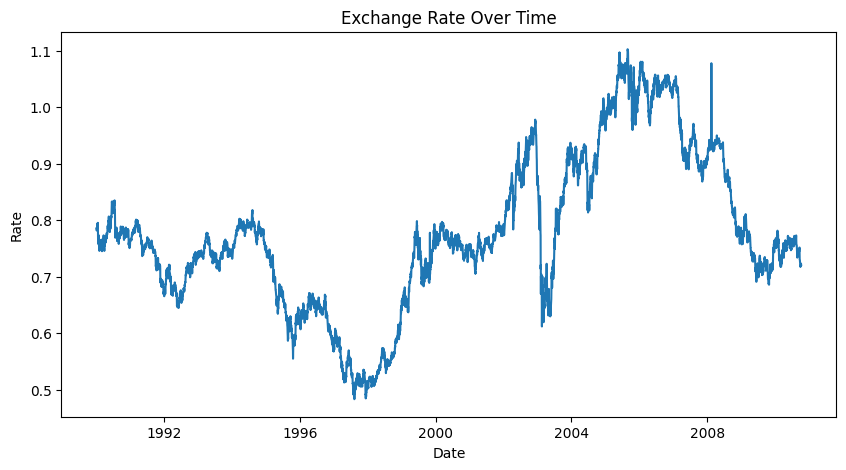

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df[rate_col])
plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.show()

In [24]:
# =============================
# Train-Test Split
# =============================

train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]

ADF Statistic: -0.9808550190079013
p-value: 0.7601827946372025


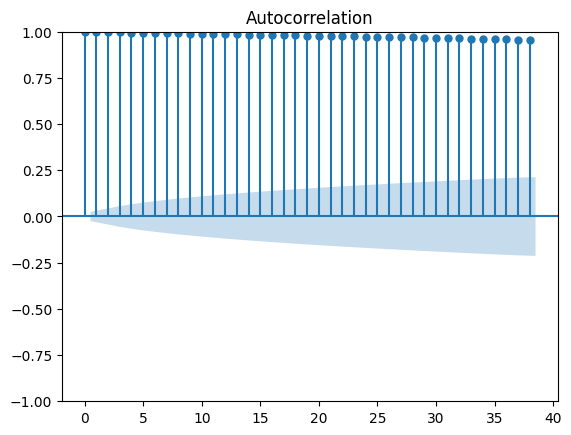

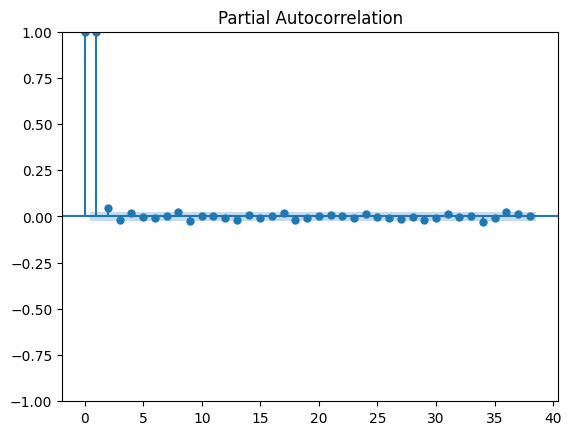

C:\Users\SS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sat, 25 Apr 2026   AIC                         -45432.092
Time:                        08:41:28   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [21]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Stationarity check
result = adfuller(train[rate_col])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Plot ACF & PACF
plot_acf(train[rate_col])
plot_pacf(train[rate_col])
plt.show()

# Fit ARIMA
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train[rate_col], order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

ADF Statistic: -0.9808550190079013
p-value: 0.7601827946372025


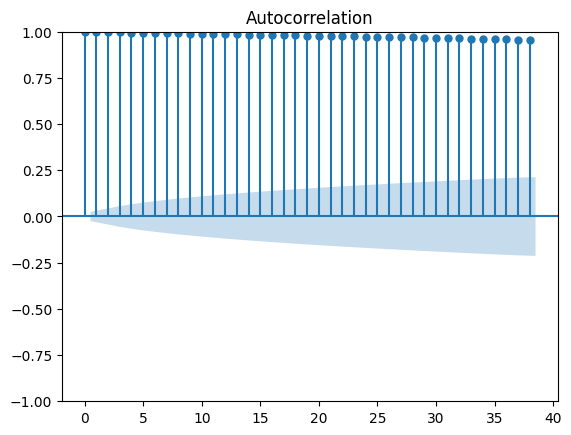

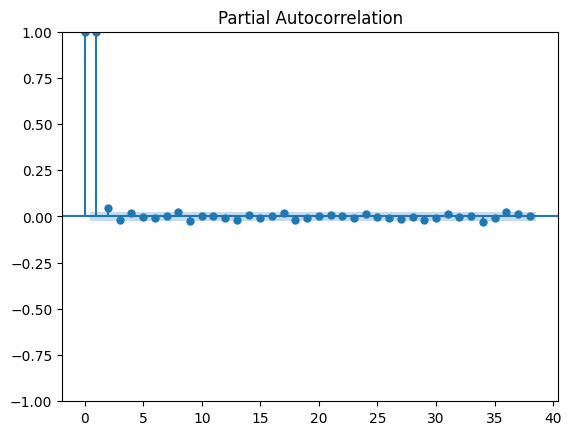

In [12]:
# Forecast
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Stationarity check
result = adfuller(train[rate_col])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Plot ACF & PACF
plot_acf(train[rate_col])
plot_pacf(train[rate_col])
plt.show()

In [23]:
# =============================
# Train-Test Split (if not already done)
# =============================
train_size = int(len(df)*0.8)
train, test = df[:train_size], df[train_size:]

# =============================
# ARIMA MODEL
# =============================
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train[rate_col], order=(1,1,1))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=len(test))

# =============================
# EXPONENTIAL SMOOTHING
# =============================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(train[rate_col], trend='add')
model_es_fit = model_es.fit()

forecast_es = model_es_fit.forecast(len(test))

# =============================
# FIX INDEX (VERY IMPORTANT)
# =============================
import pandas as pd

forecast_arima = pd.Series(forecast_arima, index=test.index)
forecast_es = pd.Series(forecast_es, index=test.index)

C:\Users\SS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ARIMA Metrics
mae_arima = mean_absolute_error(test[rate_col], forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test[rate_col], forecast_arima))
mape_arima = np.mean(np.abs((test[rate_col] - forecast_arima) / test[rate_col])) * 100

# ES Metrics
mae_es = mean_absolute_error(test[rate_col], forecast_es)
rmse_es = np.sqrt(mean_squared_error(test[rate_col], forecast_es))
mape_es = np.mean(np.abs((test[rate_col] - forecast_es) / test[rate_col])) * 100

print("\nARIMA Metrics:")
print(mae_arima, rmse_arima, mape_arima)

print("\nExponential Smoothing Metrics:")
print(mae_es, rmse_es, mape_es)


ARIMA Metrics:
0.17770970449121345 0.2054366965966928 22.797966173811552

Exponential Smoothing Metrics:
0.19027267219127425 0.22008426144336735 24.412600948256333


In [17]:
!pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
